In [5]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("data/ejendomsdata.csv")


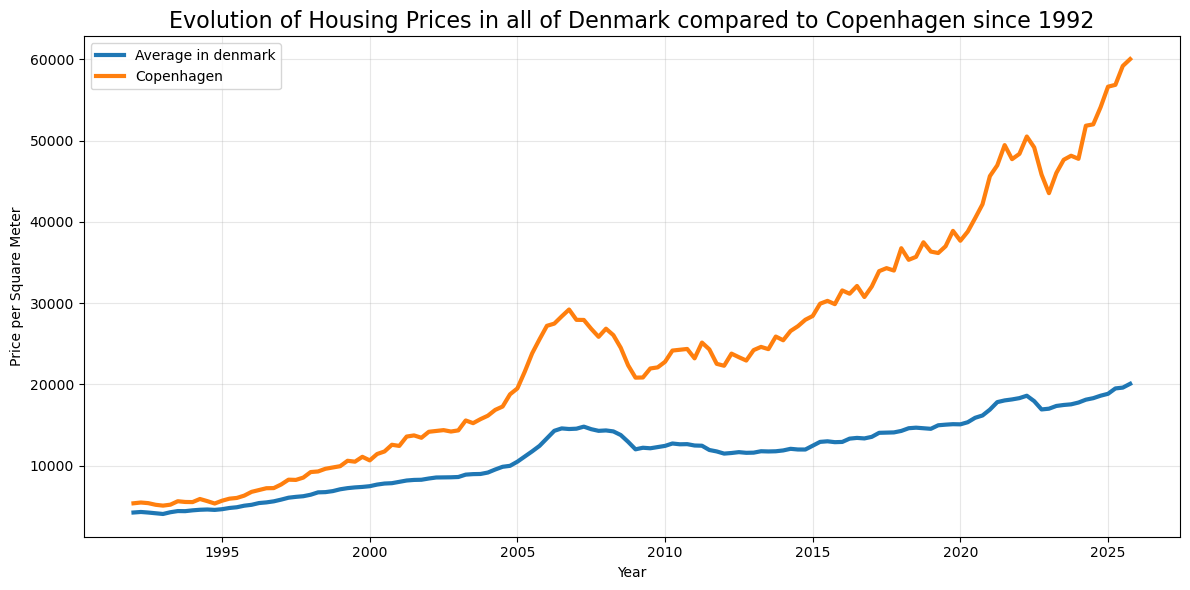

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# assuming dataframe = df

# --- Wide to long ---
long_df = df.melt(
    id_vars="kommune",
    var_name="quarter",
    value_name="price"
)

# --- Extract time ---
long_df["year"] = long_df["quarter"].str[:4].astype(int)
long_df["q"] = long_df["quarter"].str[-1].astype(int)
long_df["time"] = long_df["year"] + (long_df["q"] - 1) / 4

# --- National average ---
avg_prices = long_df.groupby("time")["price"].mean().reset_index()

# --- København only ---
kbh = long_df[long_df["kommune"] == "København"]

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(
    avg_prices["time"],
    avg_prices["price"],
    lw=3,
    label="Average in denmark"
)

plt.plot(
    kbh["time"],
    kbh["price"],
    lw=3,
    label="Copenhagen"
)

plt.title("Evolution of Housing Prices in all of Denmark compared to Copenhagen since 1992", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Price per Square Meter")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

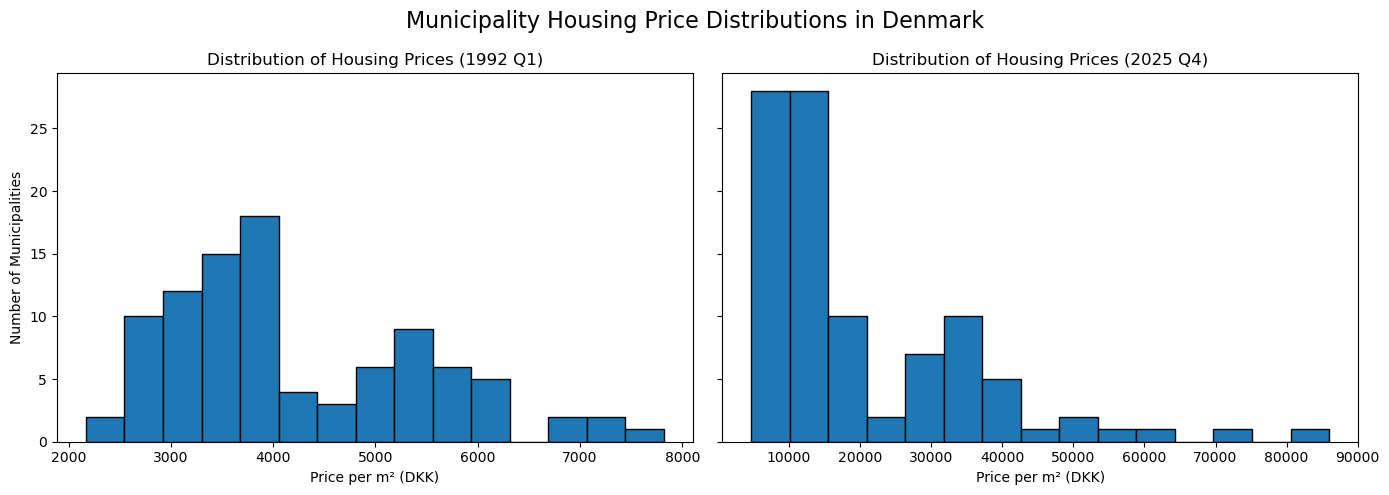

In [13]:
import matplotlib.pyplot as plt

# choose columns
col1 = "1992K1"
col2 = "2025K4"

# create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 1992 distribution
axes[0].hist(df[col1].dropna(), bins=15, edgecolor="black")
axes[0].set_title("Distribution of Housing Prices (1992 Q1)")
axes[0].set_xlabel("Price per m² (DKK)")
axes[0].set_ylabel("Number of Municipalities")

# 2025 distribution
axes[1].hist(df[col2].dropna(), bins=15, edgecolor="black")
axes[1].set_title("Distribution of Housing Prices (2025 Q4)")
axes[1].set_xlabel("Price per m² (DKK)")

plt.suptitle("Municipality Housing Price Distributions in Denmark", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
df_growth = df.copy()

first_col = df_growth.columns[1]
last_col = df_growth.columns[-1]

df_growth["pct_change"] = (
    (df_growth[last_col] - df_growth[first_col]) / df_growth[first_col]
) * 100

df_growth = df_growth.sort_values("pct_change", ascending=False)

print(df_growth[["kommune", first_col, last_col, "pct_change"]].head(10))



print(df_growth[["kommune", first_col, last_col, "pct_change"]].tail(10))

           kommune  1992K1   2025K4   pct_change
1    Frederiksberg  5183.0  85967.0  1558.633996
0        København  5355.0  60048.0  1021.344538
7         Gentofte  6783.0  70210.0   935.087719
8         Gladsaxe  6157.0  48209.0   682.994965
14  Lyngby-Taarbæk  6937.0  53909.0   677.122676
11        Hvidovre  5399.0  41724.0   672.809780
15         Rødovre  5684.0  40570.0   613.757917
3           Tårnby  5747.0  39559.0   588.341744
27       Rudersdal  7295.0  48931.0   570.747087
21          Furesø  6256.0  40754.0   551.438619
              kommune  1992K1   2025K4  pct_change
84              Skive  3169.0   7135.0  125.149890
88      Frederikshavn  3640.0   8100.0  122.527473
83  Ringkøbing-Skjern  3209.0   7050.0  119.694609
85             Struer  3380.0   7176.0  112.307692
63             Tønder  2734.0   5765.0  110.863204
38            Lolland  2588.0   4697.0   81.491499
93              Morsø  2706.0   4902.0   81.152993
28           Bornholm     NaN  11309.0         NaN
55

In [ ]:
import pandas as pd
import plotly.express as px
import json

with open("data/kommuneinddeling.geojson", "r", encoding="utf-8") as f:
    geojson = json.load(f)

In [1]:
import folium

m = folium.Map(location=[56.1, 10.0], zoom_start=7, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=geojson,
    name="choropleth",
    data=df_growth,
    columns=["kommune", "pct_change"],
    key_on="feature.properties.navn",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.2,
    legend_name="Price growth from 1992 to 2025 (%)",
    nan_fill_color="lightgray"
).add_to(m)

# --- tooltip with municipality + growth ---
# make lookup dictionary
growth_lookup = dict(zip(df_growth["kommune"], df_growth["pct_change"]))

for feature in geojson["features"]:
    kommune_name = feature["properties"]["navn"]
    pct = growth_lookup.get(kommune_name, None)

    if pct is not None:
        tooltip_text = f"{kommune_name}<br>Growth: {pct:.1f}%"
    else:
        tooltip_text = f"{kommune_name}<br>No data"

    folium.GeoJson(
        feature,
        style_function=lambda x: {
            "fillColor": "transparent",
            "color": "transparent",
            "weight": 0
        },
        tooltip=folium.Tooltip(tooltip_text)
    ).add_to(m)

folium.LayerControl().add_to(m)

m

NameError: name 'geojson' is not defined